In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Overview
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn distribution:")
print(df['Churn'].value_counts(normalize=True).round(3))

Shape: (7043, 21)

Dtypes:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0


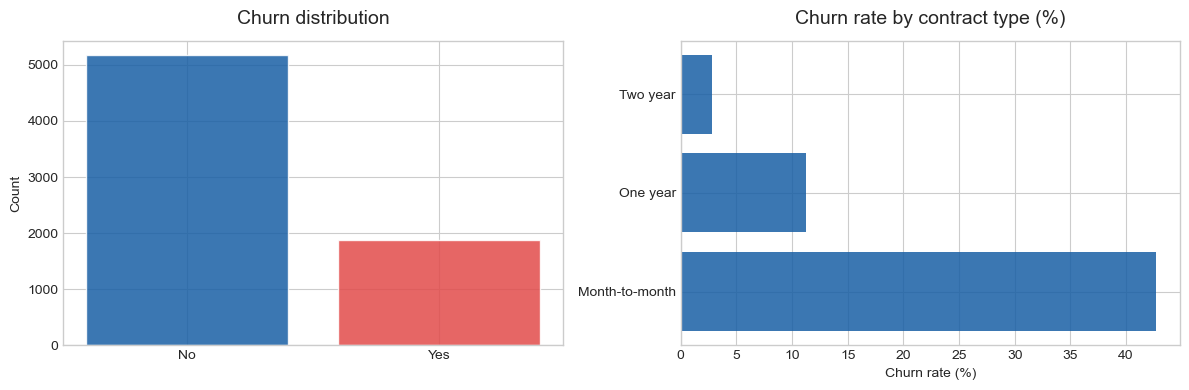

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn count
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, 
            color=['#185FA5', '#E24B4A'], alpha=0.85, edgecolor='white')
axes[0].set_title('Churn distribution', fontsize=14, pad=12)
axes[0].set_ylabel('Count')

# Churn by contract type
ct = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
)
axes[1].barh(ct.index, ct.values, color='#185FA5', alpha=0.85)
axes[1].set_title('Churn rate by contract type (%)', fontsize=14, pad=12)
axes[1].set_xlabel('Churn rate (%)')

plt.tight_layout()
plt.savefig('../data/churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

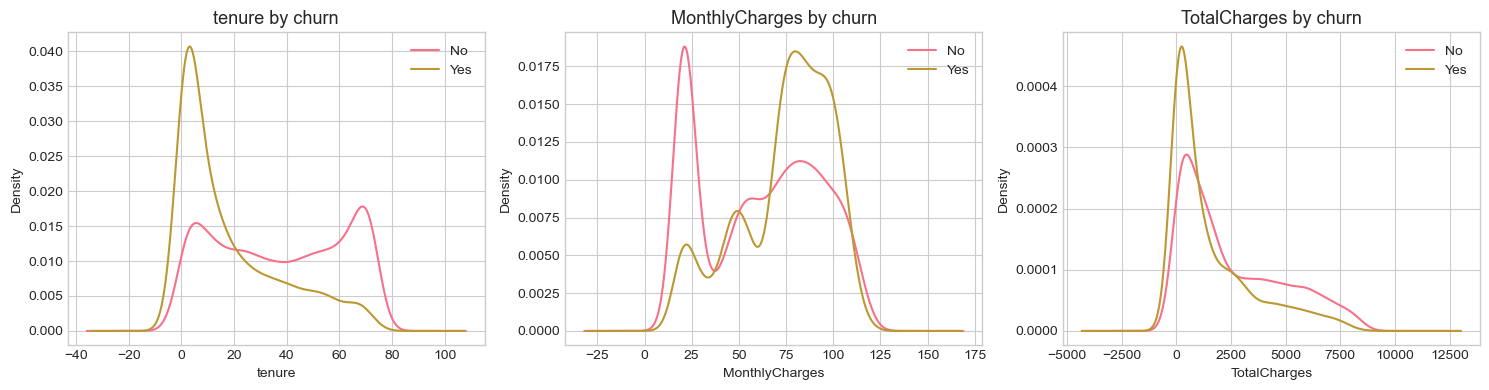

In [4]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    df.groupby('Churn')[col].plot(
        kind='kde', ax=axes[i], legend=True
    )
    axes[i].set_title(f'{col} by churn', fontsize=13)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

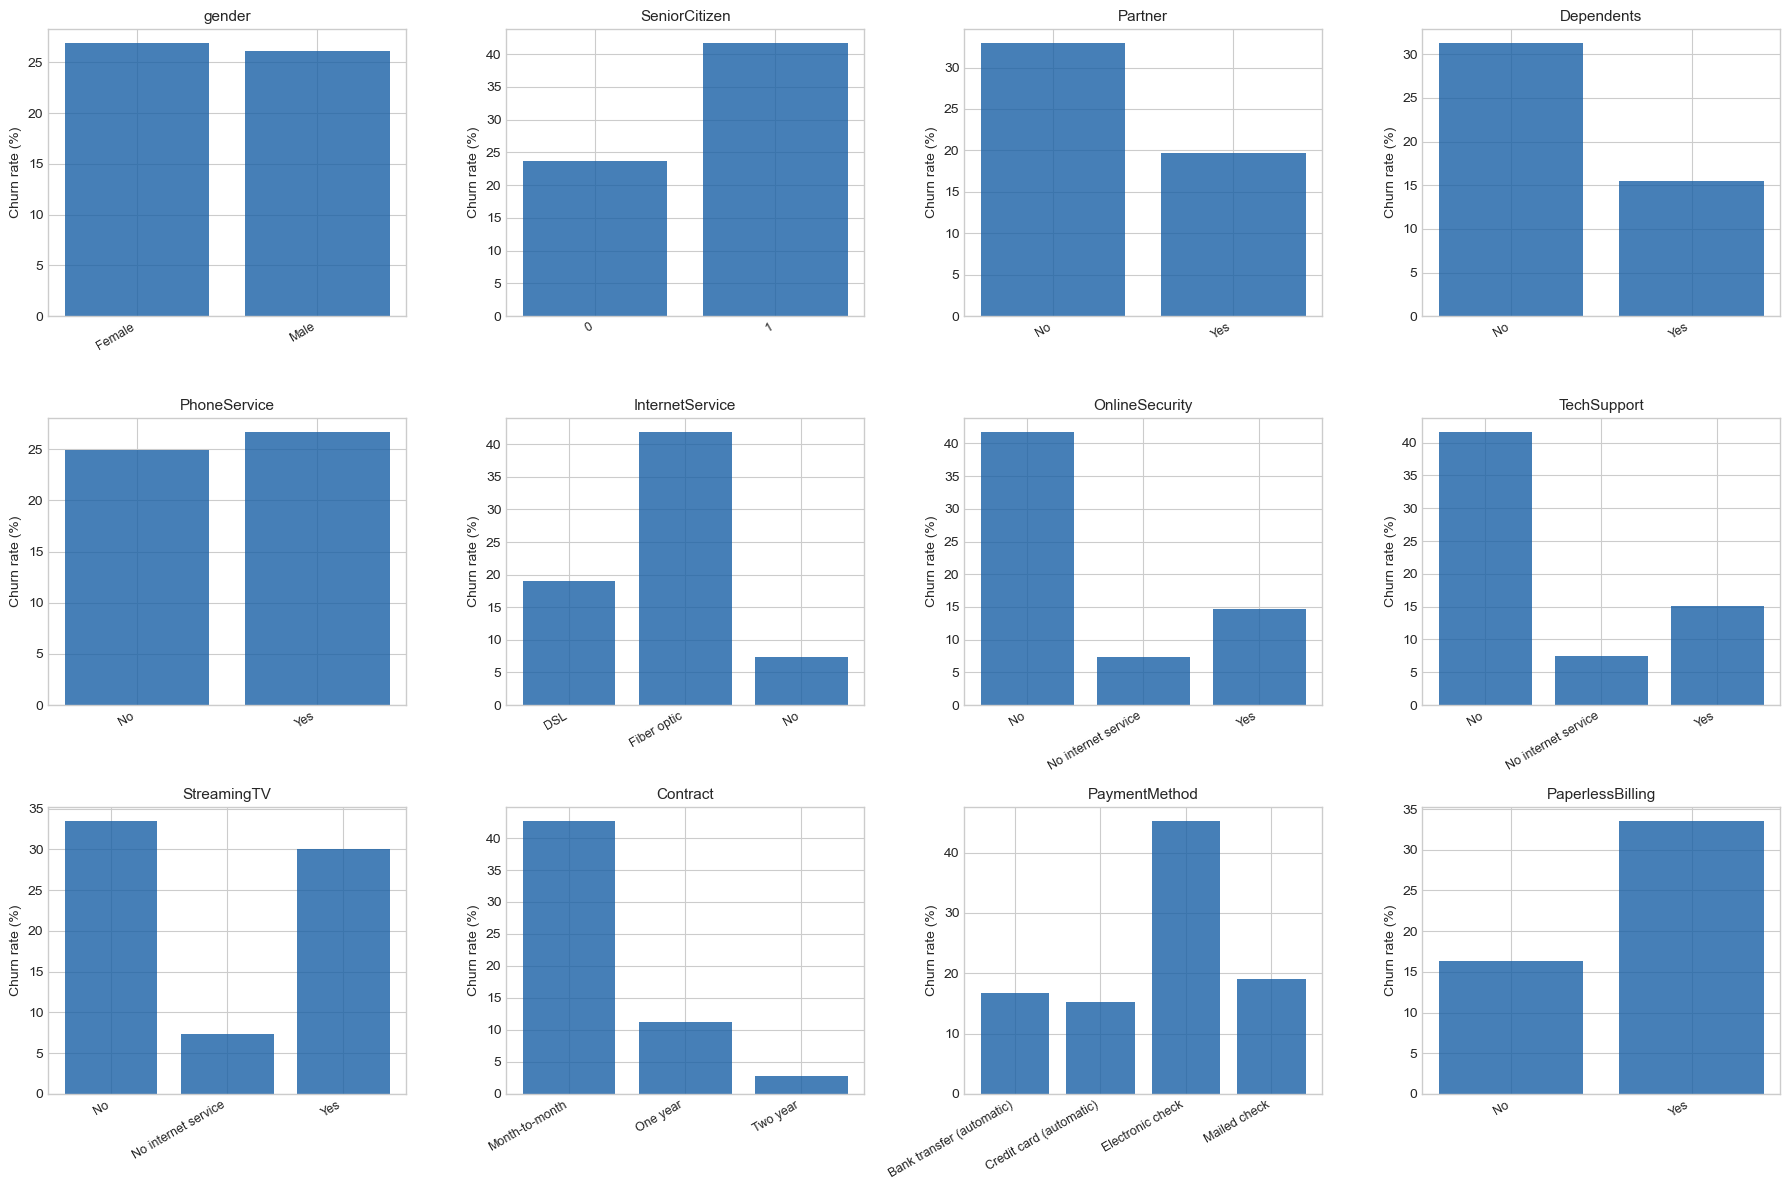

In [5]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 
            'Dependents', 'PhoneService', 'InternetService', 
            'OnlineSecurity', 'TechSupport', 'StreamingTV',
            'Contract', 'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    )
    axes[i].bar(range(len(churn_rate)), churn_rate.values,
                color='#185FA5', alpha=0.8)
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Churn rate (%)')

plt.tight_layout()
plt.savefig('../data/categorical_churn.png', dpi=150, bbox_inches='tight')
plt.show()